In [1]:
# Step 1: Environment setup
# Google Drive is mounted and required libraries are imported.

from google.colab import drive
import pandas as pd
import numpy as np

# Google Drive is mounted to access the project data directory
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Step 2: Data loading and initial inspection
# The verified-review corpus produced in the data collection stage
# is read from Google Drive and its structure is inspected.

# The verified reviews dataset is loaded from the project data directory
df = pd.read_csv('/content/drive/MyDrive/MSc-Project/data/reviews_verified.csv')

# The shape, column names, and data types are displayed for verification
print("Dataset shape:", df.shape)
print("\nColumns and data types:")
print(df.dtypes)

# Missing values are counted for each column
print("\nMissing values per column:")
print(df.isnull().sum())

# A small sample of rows is displayed for visual inspection
df.head(3)

Dataset shape: (93331, 13)

Columns and data types:
rating               float64
title                 object
text                  object
images                object
asin                  object
parent_asin           object
user_id               object
timestamp              int64
helpful_vote           int64
verified_purchase       bool
review_date           object
review_length          int64
word_count             int64
dtype: object

Missing values per column:
rating                0
title                30
text                 36
images                0
asin                  0
parent_asin           0
user_id               0
timestamp             0
helpful_vote          0
verified_purchase     0
review_date           0
review_length         0
word_count            0
dtype: int64


,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase,review_date,review_length,word_count
0,5.0,looks good,easy to see and people comment on the style,[],B00QGP1G4C,B00QGP1G4C,AFSCIIUVQYVEVKSUYGVEC7G2QS4A,1433791491000,0,True,2015-06-08 19:24:51.000,43,9
1,5.0,If you can't get the part you need then it may...,I used the bowl on the old carb because the bo...,[],B0184E3FT6,B0184E3FT6,AGJFAZIZMXOLMBMKIH2HTYJYDXWQ,1538045567884,0,True,2018-09-27 10:52:47.884,74,18
2,1.0,Do not buy,The colors are washed out and mire brown than ...,[],B096VLVJLK,B096VLVJLK,AEPIS7WVX32OKME3SZRLLSFL6HJQ,1636221610720,0,True,2021-11-06 18:00:10.720,121,22


In [3]:
# Step 3: Removal of missing values and duplicates
# Rows with missing review text are removed, as text is the primary
# input to the sentiment analysis pipeline. Duplicate reviews are
# identified and removed to prevent repeated observations from
# biasing the analysis. The count at each stage is recorded so that
# the preprocessing summary can be generated programmatically.

# The size of the corpus on entry is recorded
n_initial = len(df)

# Rows with missing review text are dropped
df = df.dropna(subset=['text']).copy()
n_after_missing = len(df)
print("Rows removed due to missing text:", n_initial - n_after_missing)

# Missing titles are replaced with an empty string, as the title is secondary
df['title'] = df['title'].fillna('')

# Duplicate reviews are identified using user, product, and text together
df = df.drop_duplicates(subset=['user_id', 'asin', 'text']).copy()
n_after_duplicates = len(df)
print("Duplicate rows removed:", n_after_missing - n_after_duplicates)

print("Remaining reviews:", n_after_duplicates)

Rows removed due to missing text: 36
Duplicate rows removed: 1
Remaining reviews: 93294


In [4]:
# Step 4: Minimal regex-based text cleaning
# A deliberately minimal cleaning strategy is applied. Embedded media
# tags, HTML fragments, URLs, and redundant whitespace are removed,
# while punctuation, capitalisation, and emoticons are retained, as
# these carry sentiment signal used by VADER and the transformer models.

import re

def clean_text(text):
    # Embedded Amazon media tags such as [[VIDEOID:...]] are removed
    text = re.sub(r'\[\[.*?\]\]', ' ', str(text))
    # HTML tags and entities are removed
    text = re.sub(r'<.*?>', ' ', text)
    text = re.sub(r'&[a-z]+;', ' ', text)
    # URLs are removed
    text = re.sub(r'http\S+|www\.\S+', ' ', text)
    # Redundant whitespace is collapsed into single spaces
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# The cleaning function is applied to the review text and title
df['clean_text'] = df['text'].apply(clean_text)
df['clean_title'] = df['title'].apply(clean_text)

# Reviews left empty after cleaning are removed
before = len(df)
df = df[df['clean_text'].str.len() > 0].copy()
print("Rows removed after cleaning (empty text):", before - len(df))

# A before-and-after example is displayed for verification
print("\nOriginal:", df['text'].iloc[2][:200])
print("\nCleaned :", df['clean_text'].iloc[2][:200])

Rows removed after cleaning (empty text): 242

Original: The colors are washed out and mire brown than gray. It is basically a piece of wallpaper. Very deceiving picture on here.

Cleaned : The colors are washed out and mire brown than gray. It is basically a piece of wallpaper. Very deceiving picture on here.


In [5]:
# Step 5: Saving the cleaned dataset and preprocessing summary
# The cleaned corpus is saved to Google Drive for use in the sentiment
# analysis pipeline. A summary table of the preprocessing steps is
# generated programmatically from the recorded stage counts, ensuring
# that the reported figures are derived directly from the data rather
# than entered manually.

import os

# The word count is recalculated on the cleaned text before saving, so
# that the exported corpus contains a length measure consistent with
# the cleaned rather than the raw text
df['clean_word_count'] = df['clean_text'].str.split().str.len()

# The stale length columns derived from the raw text are removed to
# avoid ambiguity in later stages of the pipeline
df = df.drop(columns=['review_length', 'word_count'], errors='ignore')

# The final corpus size is recorded
n_final = len(df)

output_data_path = '/content/drive/MyDrive/MSc-Project/data/reviews_cleaned.csv'
output_dir = '/content/drive/MyDrive/MSc-Project/outputs'
os.makedirs(output_dir, exist_ok=True)

# The cleaned dataset is saved to the project data directory
df.to_csv(output_data_path, index=False)
print("Cleaned dataset saved:", output_data_path)
print("Final shape:", df.shape)

# The summary table is constructed from the recorded stage counts
summary = pd.DataFrame({
    'Preprocessing step': [
        'Initial verified-review corpus',
        'Removal of missing review text',
        'Removal of duplicate reviews',
        'Regex cleaning (media tags, HTML, URLs, whitespace)',
        'Final cleaned corpus'
    ],
    'Reviews remaining': [
        n_initial,
        n_after_missing,
        n_after_duplicates,
        n_final,
        n_final
    ],
    'Reviews removed': [
        0,
        n_initial - n_after_missing,
        n_after_missing - n_after_duplicates,
        n_after_duplicates - n_final,
        n_initial - n_final
    ]
})

# The summary table is exported to CSV for the dissertation
summary_path = os.path.join(output_dir, 'preprocessing_summary_table.csv')
summary.to_csv(summary_path, index=False)
print("\nSummary table saved:", summary_path)
print(f"Retention rate: {n_final / n_initial:.2%}")
summary

Cleaned dataset saved: /content/drive/MyDrive/MSc-Project/data/reviews_cleaned.csv
Final shape: (93052, 14)

Summary table saved: /content/drive/MyDrive/MSc-Project/outputs/preprocessing_summary_table.csv
Retention rate: 99.70%


,Preprocessing step,Reviews remaining,Reviews removed
0,Initial verified-review corpus,93331,0
1,Removal of missing review text,93295,36
2,Removal of duplicate reviews,93294,1
3,"Regex cleaning (media tags, HTML, URLs, whites...",93052,242
4,Final cleaned corpus,93052,279


count    93052.000000
mean        30.979485
std         41.295936
min          1.000000
25%          8.000000
50%         19.000000
75%         39.000000
max       1437.000000
Name: clean_word_count, dtype: float64


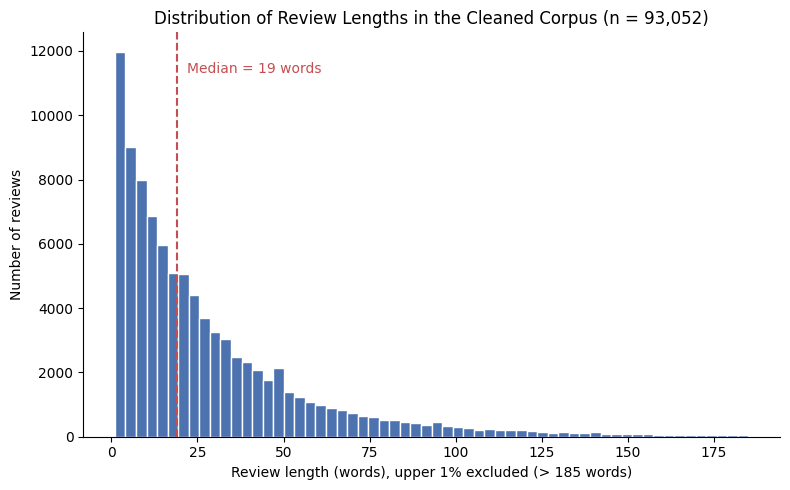

Figure saved: /content/drive/MyDrive/MSc-Project/outputs/review_length_distribution.png


In [7]:
# Step 6: Review length distribution of the cleaned corpus
# The distribution of review word counts is visualised to characterise
# the corpus prior to sentiment analysis. Reviews above the 99th
# percentile are excluded from the plot rather than truncated, as
# truncation would create an artificial peak at the upper boundary.
# The excluded proportion is reported in the axis label for
# transparency. The figure is saved at 300 dpi for direct inclusion in
# the dissertation.

import matplotlib.pyplot as plt

# Descriptive statistics of the cleaned review lengths are displayed
print(df['clean_word_count'].describe())

# The upper one percent of reviews is excluded to improve readability
cap = df['clean_word_count'].quantile(0.99)
plot_values = df.loc[df['clean_word_count'] <= cap, 'clean_word_count']

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(plot_values, bins=60, color='#4C72B0', edgecolor='white')

ax.set_xlabel(f'Review length (words), upper 1% excluded (> {cap:.0f} words)')
ax.set_ylabel('Number of reviews')

# The full sample size is inserted into the title programmatically
ax.set_title(f'Distribution of Review Lengths in the Cleaned Corpus (n = {len(df):,})')

# The median is marked to make the central tendency visible
median_val = df['clean_word_count'].median()
ax.axvline(median_val, color='#C44E52', linestyle='--', linewidth=1.5)
ax.text(median_val + 3, ax.get_ylim()[1] * 0.9,
        f'Median = {median_val:.0f} words', color='#C44E52', fontsize=10)

ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()

# The figure is saved at 300 dpi to the project outputs directory
fig_path = '/content/drive/MyDrive/MSc-Project/outputs/review_length_distribution.png'
plt.savefig(fig_path, dpi=300)
plt.show()
print("Figure saved:", fig_path)